# No-Show / Cancellation Prediction

**Goal:** for each booking, predict the probability that the customer won't show up.
Owners use this to flag risky bookings so they can confirm with the customer or
oversell the slot.

**The ML task:** *binary classification* — input = booking features, output = 0 (will show) or 1 (won't).

## 1. Load the data and check class balance

In classification, we always check **how rare each class is**. If only 8% of
bookings are no-shows, a dumb model that always predicts "will show" gets 92%
accuracy — and is useless. **Class imbalance changes how we measure success.**

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv("../data/bookings_labeled.csv", parse_dates=["timestamp"])
print(f"Rows: {len(df):,}")
print(df["status"].value_counts(normalize=True).round(3))

# Treat both no_show and cancelled as "missed" (positive class)
df["is_missed"] = df["status"].isin(["no_show","cancelled"]).astype(int)
print(f"\nMissed rate: {df['is_missed'].mean():.1%}")
df.head()

Rows: 10,454
status
completed    0.743
no_show      0.209
cancelled    0.047
Name: proportion, dtype: float64

Missed rate: 25.7%


,timestamp,court_id,sport,district,day_of_week,hour,is_weekend,is_holiday,weather,price,n_courts,bookings,lead_time_days,is_repeat_customer,status,is_missed
0,2026-02-10 11:00:00,bbc-01,Badminton,Sukhumvit,1,11,False,False,rainy,450,4,1,2,True,no_show,1
1,2026-02-10 12:00:00,bbc-01,Badminton,Sukhumvit,1,12,False,False,rainy,450,4,1,6,True,completed,0
2,2026-02-10 13:00:00,bbc-01,Badminton,Sukhumvit,1,13,False,False,rainy,450,4,1,23,True,completed,0
3,2026-02-10 14:00:00,bbc-01,Badminton,Sukhumvit,1,14,False,False,rainy,450,4,1,29,False,cancelled,1
4,2026-02-10 15:00:00,bbc-01,Badminton,Sukhumvit,1,15,False,False,rainy,450,4,2,23,False,no_show,1


## 2. Visualize: who no-shows?

Looking at the miss rate broken down by each feature tells us which signals
the model will likely use.

/var/folders/rf/4sxqbs3d5tjg8t617zckblyx1rl7px/T/ipykernel_1499/1210506651.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["lead_time_days"], bins=[-1,3,7,14,30]))["is_missed"].mean().plot(


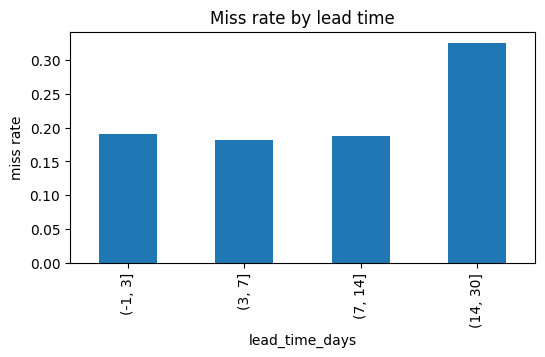

In [2]:
df.groupby(pd.cut(df["lead_time_days"], bins=[-1,3,7,14,30]))["is_missed"].mean().plot(
    kind="bar", figsize=(6,3), title="Miss rate by lead time"
)
plt.ylabel("miss rate"); plt.show()

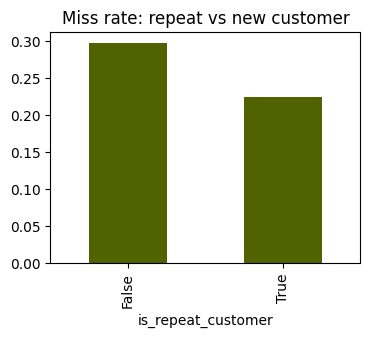

In [3]:
df.groupby("is_repeat_customer")["is_missed"].mean().plot(
    kind="bar", figsize=(4,3), title="Miss rate: repeat vs new customer", color="#506300"
)
plt.show()

/var/folders/rf/4sxqbs3d5tjg8t617zckblyx1rl7px/T/ipykernel_1499/1844433707.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["price"], bins=[0,400,700,2000]))["is_missed"].mean().plot(


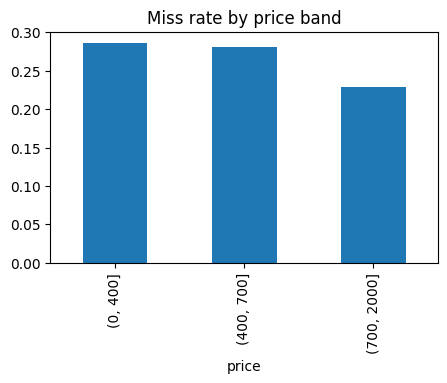

In [4]:
df.groupby(pd.cut(df["price"], bins=[0,400,700,2000]))["is_missed"].mean().plot(
    kind="bar", figsize=(5,3), title="Miss rate by price band"
)
plt.show()

**Pattern check:** miss rate should rise with longer lead time and drop for
repeat customers. Those are the signals we baked into the data — confirming
the model has something real to learn.

## 3. Feature engineering

Same idea as Notebook 1 — turn categoricals into 0/1 columns.

In [5]:
features = pd.get_dummies(
    df[["sport","district","day_of_week","hour","is_weekend","is_holiday",
        "weather","price","lead_time_days","is_repeat_customer"]],
    columns=["sport","district","weather"],
    drop_first=True,
)
target = df["is_missed"]
print("Feature matrix:", features.shape)
features.head()

Feature matrix: (10454, 14)


,day_of_week,hour,is_weekend,is_holiday,price,lead_time_days,is_repeat_customer,sport_Basketball,sport_Football,sport_Padel,district_Sukhumvit,district_Thong Lor,weather_rainy,weather_sunny
0,1,11,False,False,450,2,True,False,False,False,True,False,True,False
1,1,12,False,False,450,6,True,False,False,False,True,False,True,False
2,1,13,False,False,450,23,True,False,False,False,True,False,True,False
3,1,14,False,False,450,29,False,False,False,False,True,False,True,False
4,1,15,False,False,450,23,False,False,False,False,True,False,True,False


## 4. Train/test split — stratified

Because the positive class is rare, a random split could land most of the
no-shows in either train or test by chance. **Stratified split** preserves the
class ratio in both halves.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)
print(f"Train miss rate: {y_train.mean():.3f}   Test miss rate: {y_test.mean():.3f}")

Train miss rate: 0.257   Test miss rate: 0.256


## 5. Baseline: Logistic Regression

Despite the name, **logistic regression is a classifier**. It outputs a
probability between 0 and 1 by squashing a weighted sum through a sigmoid:

`P(missed) = 1 / (1 + exp(−(w·x + b)))`

We evaluate with:
- **Confusion matrix** — counts of TP / FP / FN / TN
- **Precision** — of the bookings we *flag* as risky, how many actually missed
- **Recall** — of the *actual* missed bookings, how many we caught
- **ROC curve / AUC** — overall ranking quality, threshold-independent

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

logit = LogisticRegression(max_iter=1000, class_weight="balanced")
logit.fit(X_train_s, y_train)
pred_logit = logit.predict(X_test_s)
prob_logit = logit.predict_proba(X_test_s)[:, 1]

print("Confusion matrix:\n", confusion_matrix(y_test, pred_logit))
print("\n", classification_report(y_test, pred_logit, target_names=["showed","missed"]))
print(f"ROC AUC: {roc_auc_score(y_test, prob_logit):.3f}")

Confusion matrix:
 [[923 632]
 [237 299]]

               precision    recall  f1-score   support

      showed       0.80      0.59      0.68      1555
      missed       0.32      0.56      0.41       536

    accuracy                           0.58      2091
   macro avg       0.56      0.58      0.54      2091
weighted avg       0.67      0.58      0.61      2091

ROC AUC: 0.600


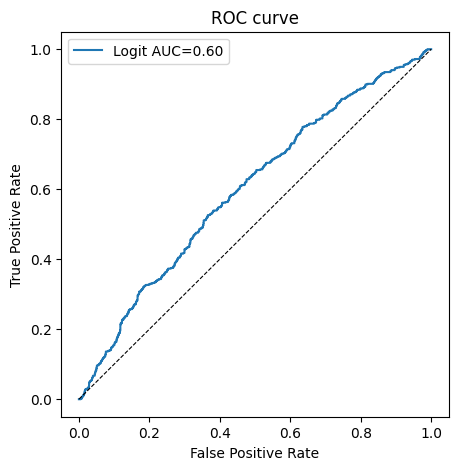

In [8]:
fpr, tpr, _ = roc_curve(y_test, prob_logit)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"Logit AUC={roc_auc_score(y_test, prob_logit):.2f}")
plt.plot([0,1],[0,1],"k--", lw=0.8)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC curve"); plt.legend(); plt.show()

## 6. What did the model learn?

Logistic regression coefficients are interpretable: a **positive** coefficient
means the feature pushes the prediction *toward* "missed". A **negative** one
pushes toward "showed up".

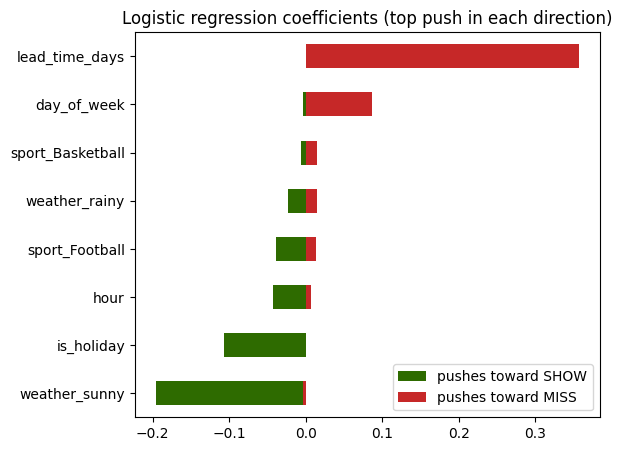

In [9]:
coefs = pd.Series(logit.coef_[0], index=features.columns).sort_values()
fig, ax = plt.subplots(figsize=(6,5))
coefs.head(8).plot(kind="barh", ax=ax, color="#2e6b00", label="pushes toward SHOW")
coefs.tail(8).plot(kind="barh", ax=ax, color="#c62828", label="pushes toward MISS")
plt.title("Logistic regression coefficients (top push in each direction)")
plt.legend(); plt.show()

**Expected:** `is_repeat_customer` should have a strong negative coefficient
(repeat customers show up); `lead_time_days` positive (long lead = forget).

## 7. Upgrade: Random Forest classifier

Same forest idea as Notebook 1, but predicting a class instead of a number.
Tree-based models don't need scaled features — we feed them the raw matrix.

In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, max_depth=10, class_weight="balanced",
    random_state=42, n_jobs=-1,
)
rf.fit(X_train, y_train)
prob_rf = rf.predict_proba(X_test)[:, 1]

print(f"Logistic AUC: {roc_auc_score(y_test, prob_logit):.3f}")
print(f"Forest   AUC: {roc_auc_score(y_test, prob_rf):.3f}")

Logistic AUC: 0.600
Forest   AUC: 0.587


## 8. Picking the Low / Medium / High thresholds

The model gives us a probability between 0 and 1. The owner UI shows three
tiers. We pick cutoffs by looking at how the population splits.

A reasonable starting point: bottom ~70% of risk = Low, next ~20% = Medium,
top ~10% = High. Check what probabilities those quantiles correspond to.

In [11]:
q70, q90 = np.quantile(prob_rf, [0.70, 0.90])
print(f"Low/Med cutoff (70th pct): {q70:.3f}")
print(f"Med/High cutoff (90th pct): {q90:.3f}")

def tier(p):
    if p < q70: return "Low"
    if p < q90: return "Medium"
    return "High"

tiers = pd.Series([tier(p) for p in prob_rf])
miss_by_tier = pd.DataFrame({"tier": tiers, "missed": y_test.values}).groupby("tier")["missed"].mean()
print("\nActual miss rate per tier:")
print(miss_by_tier.round(3))

Low/Med cutoff (70th pct): 0.500
Med/High cutoff (90th pct): 0.593

Actual miss rate per tier:
tier
High      0.362
Low       0.229
Medium    0.299
Name: missed, dtype: float64


**Sanity check:** High tier should have a substantially higher actual miss rate
than Low. If the tiers don't separate, the model has no real signal — we'd need
better features.

## 9. Save the model

We save the trained forest **and** the cutoff thresholds, so the app uses
exactly the same tier logic you saw here.

In [12]:
import joblib, os
os.makedirs("../models", exist_ok=True)
artifact = {
    "model": rf,
    "feature_columns": list(features.columns),
    "threshold_low_med": float(q70),
    "threshold_med_high": float(q90),
}
joblib.dump(artifact, "../models/noshow_rf.pkl")
print("Saved noshow_rf.pkl")

Saved noshow_rf.pkl
